In [1]:
import torch
print("CUDA Available:", torch.cuda.is_available())                                        
if torch.cuda.is_available():                                                              


CUDA Available: True
Device: NVIDIA GeForce RTX 5090


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
import nltk

# Download NLTK resources for upcoming preprocessing
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('punkt_tab')
# Set visual style for our plots
sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')



Libraries imported successfully!


[nltk_data] Downloading package stopwords to /home/user6/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /home/user6/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /home/user6/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/user6/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [3]:
# The dataset author provided the raw CSVs directly on their repo
train_url = "https://huggingface.co/datasets/juliensimon/autonlp-data-song-lyrics/resolve/main/raw/train2.csv"
val_url = "https://huggingface.co/datasets/juliensimon/autonlp-data-song-lyrics/resolve/main/raw/val2.csv"

print("Downloading CSVs...")
df_train = pd.read_csv(train_url)
df_val = pd.read_csv(val_url)

# Let's combine them for our Exploratory Data Analysis (EDA)
df = pd.concat([df_train, df_val], ignore_index=True)

# The dataset columns are usually 'text' (lyrics) and something like 'label' or 'target'
# Let's standardize the column names just in case
if 'label' not in df.columns and 'target' in df.columns:
    df.rename(columns={'target': 'label'}, inplace=True)

print(f"Dataset successfully loaded! Total rows: {len(df)}")


Dataset successfully loaded! Total rows: 53882


,Lyric,Genre0
0,[Intro: Method Man w/ sample] + (Sunny valenti...,Hip Hop
1,[Sean Paul:]. Aye. It's Sean Paul 'long side. ...,Pop
2,Beauty finds refuge in herself. Lovers wrapped...,Indie
3,You've changed your tune. many times since we'...,Rock
4,I got all these J's rolled up. And got all the...,Hip Hop


In [4]:
# Cell 2.5: Standardize column names
df.rename(columns={'Lyric': 'text', 'Genre0': 'label'}, inplace=True)

# Verify the changes and check the exact class labels
display(df.head())


,text,label
0,[Intro: Method Man w/ sample] + (Sunny valenti...,Hip Hop
1,[Sean Paul:]. Aye. It's Sean Paul 'long side. ...,Pop
2,Beauty finds refuge in herself. Lovers wrapped...,Indie
3,You've changed your tune. many times since we'...,Rock
4,I got all these J's rolled up. And got all the...,Hip Hop



Unique Genres:
 label
Rock           21103
Pop            12406
Hip Hop         9862
Indie           5708
Heavy Metal     3037
Dance           1766
Name: count, dtype: int64


Missing Values:
 text     0
label    0
dtype: int64

Duplicate Rows: 201


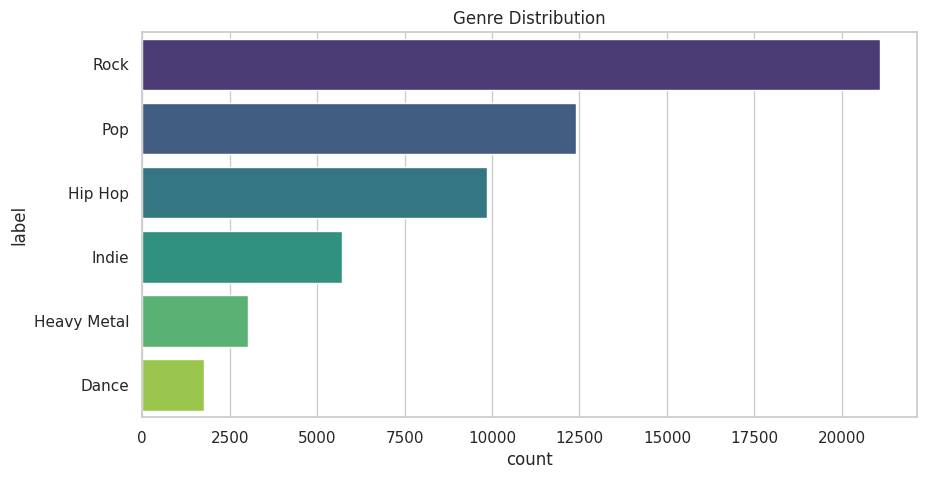


Average word count: 282.39


In [5]:
# Cell 3: EDA - Missing Values, Duplicates, and Class Distribution
print("Missing Values:\n", df.isnull().sum())
print(f"\nDuplicate Rows: {df.duplicated().sum()}")

plt.figure(figsize=(10, 5))
sns.countplot(data=df, y='label', order=df['label'].value_counts().index, palette='viridis')
plt.title('Genre Distribution')
plt.show()

# Calculate word counts for sequence length decisions
df['word_count'] = df.iloc[:, 0].astype(str).apply(lambda x: len(x.split()))


In [6]:
# Cell 3.1: Drop duplicates
df = df.drop_duplicates(subset=['text'], keep='first').reset_index(drop=True)


Dataset size after dropping duplicates: 53609


In [7]:
from sklearn.utils.class_weight import compute_class_weight

# Cell 3.2: Compute Class Weights
classes = np.unique(df['label'])
weights = compute_class_weight(class_weight='balanced', classes=classes, y=df['label'])
class_weights = dict(zip(classes, weights))

print("Class Weights:")
for genre, weight in class_weights.items():


Class Weights:
Dance: 5.1085
Heavy Metal: 2.9468
Hip Hop: 0.9125
Indie: 1.5764
Pop: 0.7249
Rock: 0.4246


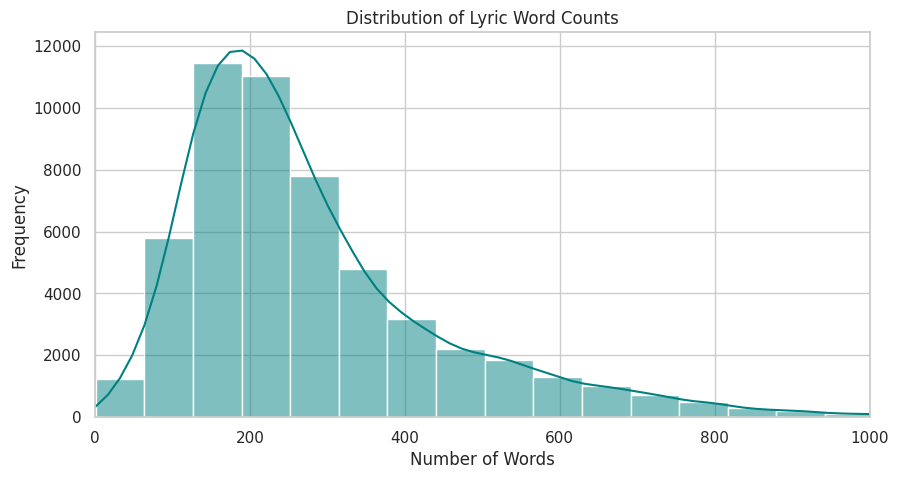

90th percentile length: 528 words


In [8]:
# Cell 3.3: Sequence Length Statistics
plt.figure(figsize=(10, 5))
sns.histplot(df['word_count'], bins=50, kde=True, color='teal')
plt.title('Distribution of Lyric Word Counts')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.xlim(0, 1000) # Capping x-axis to zoom in on the majority distribution
plt.show()

# Calculate percentiles for token limit decisions


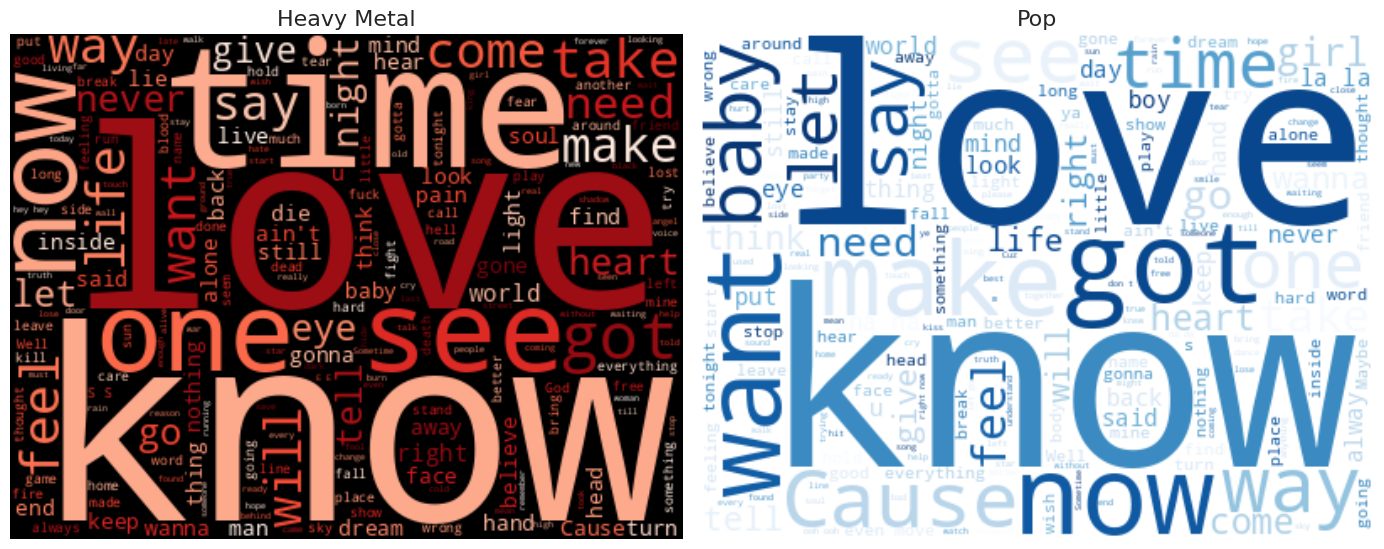

In [9]:
# Cell 3.4: Word Clouds for Genre Comparison (Heavy Metal vs. Pop)
from wordcloud import WordCloud, STOPWORDS

# Extract text for specific genres
metal_text = " ".join(text for text in df[df['label'] == 'Heavy Metal']['text'])
pop_text = " ".join(text for text in df[df['label'] == 'Pop']['text'])

# Define basic stopwords specific to song lyrics for cleaner visuals
wc_stopwords = set(STOPWORDS)
wc_stopwords.update(['chorus', 'verse', 'intro', 'outro', 'im', 'ill', 'oh', 'yeah'])

# Generate Word Clouds
wc_metal = WordCloud(width=400, height=300, background_color='black',
                     stopwords=wc_stopwords, colormap='Reds').generate(metal_text)
wc_pop = WordCloud(width=400, height=300, background_color='white',
                   stopwords=wc_stopwords, colormap='Blues').generate(pop_text)

# Plot side by side
fig, ax = plt.subplots(1, 2, figsize=(14, 7))
ax[0].imshow(wc_metal, interpolation='bilinear')
ax[0].set_title('Heavy Metal', fontsize=16)
ax[0].axis('off')

ax[1].imshow(wc_pop, interpolation='bilinear')
ax[1].set_title('Pop', fontsize=16)
ax[1].axis('off')

plt.tight_layout()


In [10]:
# Cell 4 (Updated): Dual Preprocessing Pipelines
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_heavy(text):
    """Strategy A: Heavy cleaning for TF-IDF and Classical ML (Removes tags)"""
    text = str(text).lower()
    text = re.sub(r'\[.*?\]|\(.*?\)', '', text) # Remove structural tags
    text = re.sub(r'\n+', ' ', text)
    text = re.sub(r'[^\w\s]', '', text)

    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    return " ".join(words)

def preprocess_minimal(text):
    """Strategy B: Minimal cleaning for Transformers (Preserves structure and grammar)"""
    text = str(text)
    # We keep structural tags, punctuation, and stopwords.
    # Just clean up the excessive newlines and spaces.
    text = re.sub(r'\n+', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

print("Applying Strategy A (Heavy Cleaning)...")
df['text_ml'] = df['text'].apply(preprocess_heavy)

print("Applying Strategy B (Minimal Cleaning)...")


Applying Strategy A (Heavy Cleaning)...
Applying Strategy B (Minimal Cleaning)...


,text,text_ml,text_dl
0,[Intro: Method Man w/ sample] + (Sunny valenti...,got butter aiyo one thing sure keep keep nice ...,[Intro: Method Man w/ sample] + (Sunny valenti...
1,[Sean Paul:]. Aye. It's Sean Paul 'long side. ...,aye sean paul long side mandem called jay sean...,[Sean Paul:]. Aye. It's Sean Paul 'long side. ...
2,Beauty finds refuge in herself. Lovers wrapped...,beauty find refuge lover wrapped inside others...,Beauty finds refuge in herself. Lovers wrapped...


In [12]:
from sklearn.model_selection import train_test_split

# Cell 5: Train/Validation/Test Split
# First split: 80% Train, 20% Temp (Val + Test)
# We stratify to maintain the exact genre imbalance across all sets
df_train, df_temp = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df['label']
)

# Second split: Divide Temp equally into 10% Validation and 10% Test
df_val, df_test = train_test_split(
    df_temp, test_size=0.5, random_state=42, stratify=df_temp['label']
)

# Extract targets
y_train = df_train['label']
y_val = df_val['label']
y_test = df_test['label']



Train Size: 42887 | Val Size: 5361 | Test Size: 5361


In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Cell 6: TF-IDF Extraction
# Limiting to 5000 max features prevents the sparse matrix from blowing up memory
tfidf = TfidfVectorizer(max_features=5000)

# Fit ONLY on training data, transform validation and test
X_train_tfidf = tfidf.fit_transform(df_train['text_ml'])
X_val_tfidf = tfidf.transform(df_val['text_ml'])
X_test_tfidf = tfidf.transform(df_test['text_ml'])



TF-IDF Matrix Shape (Train): (42887, 5000)


In [14]:
import numpy as np
!pip install gensim
from gensim.models import Word2Vec

# Cell 7: Word2Vec Embeddings
print("Training Word2Vec model on lyrics corpus...")
# Word2Vec requires a list of tokenized words
train_sentences = [text.split() for text in df_train['text_ml']]

# Train the Word2Vec model (vector_size=100 is standard for baseline tasks)
w2v_model = Word2Vec(sentences=train_sentences, vector_size=100, window=5, min_count=2, workers=4)

def get_document_vector(text, model):
    """Averages word vectors to create a single vector for the entire lyric"""
    words = text.split()
    # Only keep words that exist in the trained Word2Vec vocabulary
    valid_words = [word for word in words if word in model.wv.key_to_index]

    if valid_words:
        return np.mean(model.wv[valid_words], axis=0)
    else:
        # Return a zero vector if the song has no recognized words
        return np.zeros(model.vector_size)

print("Applying Word2Vec transformations to datasets...")
X_train_w2v = np.array([get_document_vector(text, w2v_model) for text in df_train['text_ml']])
X_val_w2v = np.array([get_document_vector(text, w2v_model) for text in df_val['text_ml']])
X_test_w2v = np.array([get_document_vector(text, w2v_model) for text in df_test['text_ml']])



Training Word2Vec model on lyrics corpus...
Applying Word2Vec transformations to datasets...
Word2Vec Matrix Shape (Train): (42887, 100)


In [15]:
# Cell 8: Metrics & Experiment Tracking Framework
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# Global list to track hyperparameter tuning runs across all models
tuning_records = []

def run_experiment(model, X_tr, y_tr, X_v, y_v, model_name, config_name, representation_name):
    """Trains a model, evaluates on validation set, and logs the metrics."""
    model.fit(X_tr, y_tr)
    preds = model.predict(X_v)

    acc = accuracy_score(y_v, preds)
    macro_f1 = f1_score(y_v, preds, average='macro')
    weighted_f1 = f1_score(y_v, preds, average='weighted')

    tuning_records.append({
        'Model': model_name,
        'Representation': representation_name,
        'Configuration': config_name,
        'Val Accuracy': round(acc, 4),
        'Val Macro F1': round(macro_f1, 4),
        'Val Weighted F1': round(weighted_f1, 4)
    })

    print(f"[{model_name} | {representation_name} | {config_name}] -> Val Acc: {acc:.4f} | Macro F1: {macro_f1:.4f}")


In [16]:
# Cell 9: Logistic Regression Tuning
from sklearn.linear_model import LogisticRegression

# Configuration definitions
lr_configs = [
    {"name": "Config 1 (C=0.1, Balanced)", "params": {"C": 0.1, "max_iter": 1000, "class_weight": "balanced", "random_state": 42}},
    {"name": "Config 2 (C=1.0, Balanced)", "params": {"C": 1.0, "max_iter": 1000, "class_weight": "balanced", "random_state": 42}},
    {"name": "Config 3 (C=10.0, Balanced)", "params": {"C": 10.0, "max_iter": 1000, "class_weight": "balanced", "random_state": 42}}
]

lr_models = {}

# Evaluate on TF-IDF
print("--- Training Logistic Regression on TF-IDF ---")
for cfg in lr_configs:
    clf = LogisticRegression(**cfg["params"])
    key = f"LR_TFIDF_{cfg['name']}"
    lr_models[key] = run_experiment(clf, X_train_tfidf, y_train, X_val_tfidf, y_val,
                                    "Logistic Regression", cfg["name"], "TF-IDF")

# Evaluate on Word2Vec
print("\n--- Training Logistic Regression on Word2Vec ---")
for cfg in lr_configs:
    clf = LogisticRegression(**cfg["params"])
    key = f"LR_W2V_{cfg['name']}"
    lr_models[key] = run_experiment(clf, X_train_w2v, y_train, X_val_w2v, y_val,


--- Training Logistic Regression on TF-IDF ---
[Logistic Regression | TF-IDF | Config 1 (C=0.1, Balanced)] -> Val Acc: 0.4122 | Macro F1: 0.3840
[Logistic Regression | TF-IDF | Config 2 (C=1.0, Balanced)] -> Val Acc: 0.4397 | Macro F1: 0.3992
[Logistic Regression | TF-IDF | Config 3 (C=10.0, Balanced)] -> Val Acc: 0.4441 | Macro F1: 0.3937

--- Training Logistic Regression on Word2Vec ---
[Logistic Regression | Word2Vec | Config 1 (C=0.1, Balanced)] -> Val Acc: 0.3772 | Macro F1: 0.3474
[Logistic Regression | Word2Vec | Config 2 (C=1.0, Balanced)] -> Val Acc: 0.3796 | Macro F1: 0.3500
[Logistic Regression | Word2Vec | Config 3 (C=10.0, Balanced)] -> Val Acc: 0.3796 | Macro F1: 0.3494


In [17]:
# Cell 10: Naive Bayes Tuning
from sklearn.naive_bayes import MultinomialNB, GaussianNB

nb_models = {}

# TF-IDF Tuning (MultinomialNB)
print("--- Training Multinomial Naive Bayes on TF-IDF ---")
nb_tfidf_configs = [
    {"name": "Config 1 (alpha=0.1)", "alpha": 0.1},
    {"name": "Config 2 (alpha=0.5)", "alpha": 0.5},
    {"name": "Config 3 (alpha=1.0)", "alpha": 1.0}
]

for cfg in nb_tfidf_configs:
    clf = MultinomialNB(alpha=cfg["alpha"])
    key = f"NB_TFIDF_{cfg['name']}"
    nb_models[key] = run_experiment(clf, X_train_tfidf, y_train, X_val_tfidf, y_val,
                                    "Multinomial Naive Bayes", cfg["name"], "TF-IDF")

# Word2Vec Tuning (GaussianNB)
print("\n--- Training Gaussian Naive Bayes on Word2Vec ---")
nb_w2v_configs = [
    {"name": "Config 1 (var_smoothing=1e-9)", "var_smoothing": 1e-9},
    {"name": "Config 2 (var_smoothing=1e-7)", "var_smoothing": 1e-7},
    {"name": "Config 3 (var_smoothing=1e-5)", "var_smoothing": 1e-5}
]

for cfg in nb_w2v_configs:
    clf = GaussianNB(var_smoothing=cfg["var_smoothing"])
    key = f"NB_W2V_{cfg['name']}"
    nb_models[key] = run_experiment(clf, X_train_w2v, y_train, X_val_w2v, y_val,


--- Training Multinomial Naive Bayes on TF-IDF ---
[Multinomial Naive Bayes | TF-IDF | Config 1 (alpha=0.1)] -> Val Acc: 0.5590 | Macro F1: 0.3067
[Multinomial Naive Bayes | TF-IDF | Config 2 (alpha=0.5)] -> Val Acc: 0.5561 | Macro F1: 0.3018
[Multinomial Naive Bayes | TF-IDF | Config 3 (alpha=1.0)] -> Val Acc: 0.5547 | Macro F1: 0.2977

--- Training Gaussian Naive Bayes on Word2Vec ---
[Gaussian Naive Bayes | Word2Vec | Config 1 (var_smoothing=1e-9)] -> Val Acc: 0.3843 | Macro F1: 0.3072
[Gaussian Naive Bayes | Word2Vec | Config 2 (var_smoothing=1e-7)] -> Val Acc: 0.3843 | Macro F1: 0.3072
[Gaussian Naive Bayes | Word2Vec | Config 3 (var_smoothing=1e-5)] -> Val Acc: 0.3843 | Macro F1: 0.3072


In [18]:
# Cell 11: Random Forest Tuning
from sklearn.ensemble import RandomForestClassifier

rf_configs = [
    {"name": "Config 1 (n_est=100, max_depth=15)", "params": {"n_estimators": 100, "max_depth": 15, "class_weight": "balanced", "random_state": 42, "n_jobs": -1}},
    {"name": "Config 2 (n_est=200, max_depth=30)", "params": {"n_estimators": 200, "max_depth": 30, "class_weight": "balanced", "random_state": 42, "n_jobs": -1}},
    {"name": "Config 3 (n_est=300, max_depth=None)", "params": {"n_estimators": 300, "max_depth": None, "class_weight": "balanced", "random_state": 42, "n_jobs": -1}}
]

rf_models = {}

print("--- Training Random Forest on TF-IDF ---")
for cfg in rf_configs:
    clf = RandomForestClassifier(**cfg["params"])
    key = f"RF_TFIDF_{cfg['name']}"
    rf_models[key] = run_experiment(clf, X_train_tfidf, y_train, X_val_tfidf, y_val,
                                    "Random Forest", cfg["name"], "TF-IDF")

print("\n--- Training Random Forest on Word2Vec ---")
for cfg in rf_configs:
    clf = RandomForestClassifier(**cfg["params"])
    key = f"RF_W2V_{cfg['name']}"
    rf_models[key] = run_experiment(clf, X_train_w2v, y_train, X_val_w2v, y_val,


--- Training Random Forest on TF-IDF ---
[Random Forest | TF-IDF | Config 1 (n_est=100, max_depth=15)] -> Val Acc: 0.4145 | Macro F1: 0.3678
[Random Forest | TF-IDF | Config 2 (n_est=200, max_depth=30)] -> Val Acc: 0.5506 | Macro F1: 0.3964
[Random Forest | TF-IDF | Config 3 (n_est=300, max_depth=None)] -> Val Acc: 0.5741 | Macro F1: 0.3356

--- Training Random Forest on Word2Vec ---
[Random Forest | Word2Vec | Config 1 (n_est=100, max_depth=15)] -> Val Acc: 0.5428 | Macro F1: 0.3652
[Random Forest | Word2Vec | Config 2 (n_est=200, max_depth=30)] -> Val Acc: 0.5574 | Macro F1: 0.3249
[Random Forest | Word2Vec | Config 3 (n_est=300, max_depth=None)] -> Val Acc: 0.5561 | Macro F1: 0.3218


In [19]:
# Cell 12: View Consolidated Hyperparameter Tuning Results
df_tuning_results = pd.DataFrame(tuning_records)


,Model,Representation,Configuration,Val Accuracy,Val Macro F1,Val Weighted F1
0,Logistic Regression,TF-IDF,"Config 2 (C=1.0, Balanced)",0.4397,0.3992,0.4638
1,Random Forest,TF-IDF,"Config 2 (n_est=200, max_depth=30)",0.5506,0.3964,0.5290
2,Logistic Regression,TF-IDF,"Config 3 (C=10.0, Balanced)",0.4441,0.3937,0.4666
3,Logistic Regression,TF-IDF,"Config 1 (C=0.1, Balanced)",0.4122,0.3840,0.4363
4,Random Forest,TF-IDF,"Config 1 (n_est=100, max_depth=15)",0.4145,0.3678,0.4176
5,Random Forest,Word2Vec,"Config 1 (n_est=100, max_depth=15)",0.5428,0.3652,0.5063
6,Logistic Regression,Word2Vec,"Config 2 (C=1.0, Balanced)",0.3796,0.3500,0.4007
7,Logistic Regression,Word2Vec,"Config 3 (C=10.0, Balanced)",0.3796,0.3494,0.4009
8,Logistic Regression,Word2Vec,"Config 1 (C=0.1, Balanced)",0.3772,0.3474,0.3986
9,Random Forest,TF-IDF,"Config 3 (n_est=300, max_depth=None)",0.5741,0.3356,0.4954



==================== LOGISTIC REGRESSION TEST REPORT ====================
              precision    recall  f1-score   support

       Dance       0.13      0.41      0.20       175
 Heavy Metal       0.21      0.56      0.31       303
     Hip Hop       0.84      0.77      0.80       979
       Indie       0.24      0.39      0.29       567
         Pop       0.45      0.36      0.40      1233
        Rock       0.64      0.36      0.46      2104

    accuracy                           0.45      5361
   macro avg       0.42      0.47      0.41      5361
weighted avg       0.55      0.45      0.47      5361


==================== MULTINOMIAL NAIVE BAYES TEST REPORT ====================
              precision    recall  f1-score   support

       Dance       0.50      0.01      0.02       175
 Heavy Metal       0.50      0.01      0.01       303
     Hip Hop       0.80      0.75      0.77       979
       Indie       0.00      0.00      0.00       567
         Pop       0.48      0.3

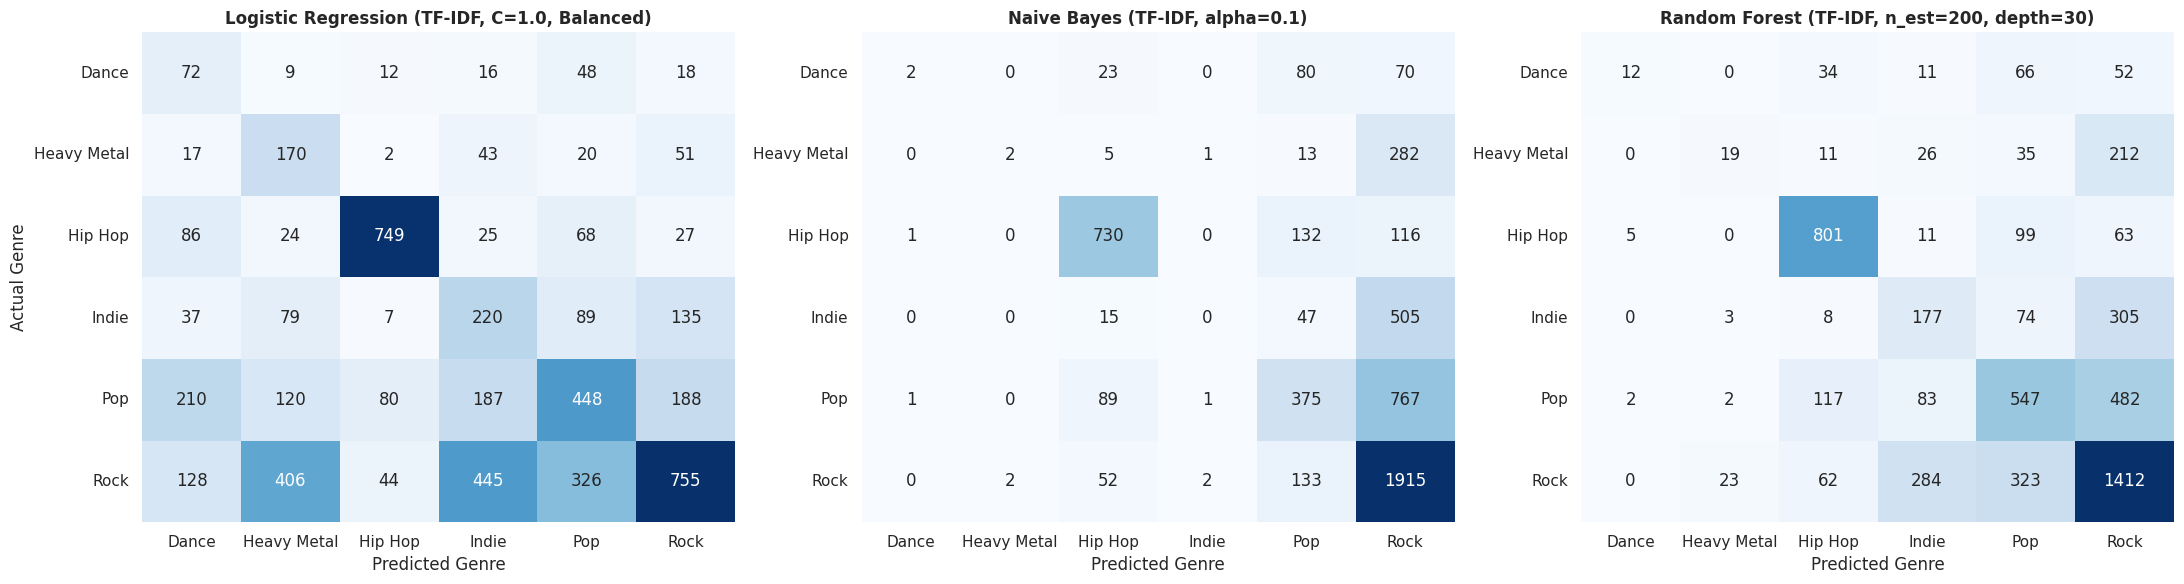

In [20]:
# Cell 13 (Updated): Test Set Evaluation & Heatmaps for Best Classical Models
from sklearn.metrics import classification_report, confusion_matrix

best_models = [
    {
        "family": "Logistic Regression",
        "title": "Logistic Regression (TF-IDF, C=1.0, Balanced)",
        "model": lr_models["LR_TFIDF_Config 2 (C=1.0, Balanced)"],
        "X_test": X_test_tfidf
    },
    {
        "family": "Multinomial Naive Bayes",
        "title": "Naive Bayes (TF-IDF, alpha=0.1)",
        "model": nb_models["NB_TFIDF_Config 1 (alpha=0.1)"],
        "X_test": X_test_tfidf
    },
    {
        "family": "Random Forest",
        "title": "Random Forest (TF-IDF, n_est=200, depth=30)",
        "model": rf_models["RF_TFIDF_Config 2 (n_est=200, max_depth=30)"],
        "X_test": X_test_tfidf
    }
]

# 1. Print Detailed Classification Reports
for bm in best_models:
    print(f"\n{'='*20} {bm['family'].upper()} TEST REPORT {'='*20}")
    preds = bm["model"].predict(bm["X_test"])
    print(classification_report(y_test, preds))

# 2. Plot Side-by-Side Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
class_labels = sorted(y_test.unique())

for idx, bm in enumerate(best_models):
    preds = bm["model"].predict(bm["X_test"])
    cm = confusion_matrix(y_test, preds, labels=class_labels)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=class_labels, yticklabels=class_labels, cbar=False)
    axes[idx].set_title(bm["title"], fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Predicted Genre')
    axes[idx].set_ylabel('Actual Genre' if idx == 0 else '')

plt.tight_layout()


In [21]:
# Cell 14: Keras Tokenization and Padding
import numpy as np
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# 1. Encode Targets
label_encoder = LabelEncoder()
y_train_idx = label_encoder.fit_transform(y_train)
y_val_idx = label_encoder.transform(y_val)
y_test_idx = label_encoder.transform(y_test)
num_classes = len(label_encoder.classes_)

# 2. Tokenize (keeping top 20,000 words)
num_words = 20000
max_len = 256

tokenizer = Tokenizer(num_words=num_words, oov_token="<OOV>")
tokenizer.fit_on_texts(df_train['text_dl'])

X_train_seq = tokenizer.texts_to_sequences(df_train['text_dl'])
X_val_seq = tokenizer.texts_to_sequences(df_val['text_dl'])
X_test_seq = tokenizer.texts_to_sequences(df_test['text_dl'])

# 3. Pad sequences
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding="post")
X_val_pad = pad_sequences(X_val_seq, maxlen=max_len, padding="post")
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding="post")


I0000 00:00:1787907565.841291     603 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787907566.135064     603 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1787907567.586726     603 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Padding complete! Train shape: (42887, 256)


In [22]:
# Cell 15: Keras Class Weights
from sklearn.utils.class_weight import compute_class_weight

classes_unique = np.unique(y_train_idx)
weights_arr = compute_class_weight(class_weight='balanced', classes=classes_unique, y=y_train_idx)


In [23]:
# Cell 16: Modular PyTorch Builder (RUNS ON RTX 5090!)                                                               
import torch                                                                                                         
import torch.nn as nn                                                                                                
                                                                                                                     
class PyTorchRecurrentModel(nn.Module):                                                                              
    def __init__(self, arch_type, vocab_size, embed_dim, hidden_dim, num_classes, dropout_rate=0.3):                 
        super().__init__()                                                                                           
        self.embedding = nn.Embedding(vocab_size, embed_dim)                                                         
                                                                                                                     
        is_bidirectional = 'Bi-' in arch_type                                                                        
        base_arch = arch_type.replace('Bi-', '')                                                                     
                                                                                                                     
        if base_arch == 'SimpleRNN':                                                                                 
            self.rnn = nn.RNN(embed_dim, hidden_dim, batch_first=True, bidirectional=is_bidirectional)               
        elif base_arch == 'GRU':                                                                                     
            self.rnn = nn.GRU(embed_dim, hidden_dim, batch_first=True, bidirectional=is_bidirectional)               
        elif base_arch == 'LSTM':                                                                                    
            self.rnn = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=is_bidirectional)              
                                                                                                                     
        self.dropout = nn.Dropout(dropout_rate)                                                                      
        rnn_out_dim = hidden_dim * 2 if is_bidirectional else hidden_dim                                             
        self.fc = nn.Linear(rnn_out_dim, num_classes)                                                                
                                                                                                                     
    def forward(self, x):                                                                                            
        x = self.embedding(x)                                                                                        
        out, _ = self.rnn(x)                                                                                         
        out = out[:, -1, :]                                                                                          
        out = self.dropout(out)                                                                                      


In [24]:
# Cell 20: Training Loop (RUNS ON RTX 5090!)                                                                                                                                                             
from sklearn.metrics import f1_score, accuracy_score                                                                                                                                                     
from torch.utils.data import TensorDataset, DataLoader                                                                                                                                                   
import torch.optim as optim                                                                                                                                                                              
import copy                                                                                                                                                                                              
import numpy as np                                                                                                                                                                                       
                                                                                                                                                                                                         
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')                                                                                                                                    
print(f"Training on: {device}")                                                                                                                              
                                                                                                                                                                                                         
batch_size = 128                                                                                                                                                                                         
train_loader = DataLoader(TensorDataset(torch.tensor(X_train_pad, dtype=torch.long), torch.tensor(y_train_idx, dtype=torch.long)), batch_size=batch_size, shuffle=True)                                  
val_loader = DataLoader(TensorDataset(torch.tensor(X_val_pad, dtype=torch.long), torch.tensor(y_val_idx, dtype=torch.long)), batch_size=batch_size, shuffle=False)                                       
                                                                                                                                                                                                         
weight_tensor = torch.tensor([keras_class_weights[i] for i in range(len(keras_class_weights))], dtype=torch.float32).to(device)                                                                          
criterion = nn.CrossEntropyLoss(weight=weight_tensor)                                                                                                                                                    
                                                                                                                                                                                                         
architectures = ['SimpleRNN', 'Bi-SimpleRNN', 'GRU', 'Bi-GRU', 'LSTM', 'Bi-LSTM']                                                                                                                        
scaled_configs = [                                                                                                                                                                                       
    {"name": "Config 1 (Embed=128, Hidden=128, Drop=0.3)", "embed_dim": 128, "hidden_dim": 128, "drop": 0.3},                                                                                            
    {"name": "Config 2 (Embed=128, Hidden=256, Drop=0.4)", "embed_dim": 128, "hidden_dim": 256, "drop": 0.4},                                                                                            
    {"name": "Config 3 (Embed=256, Hidden=128, Drop=0.5)", "embed_dim": 256, "hidden_dim": 128, "drop": 0.5}                                                                                             
]                                                                                                                                                                                                        
                                                                                                                                                                                                         
trained_pytorch_models = {}                                                                                                                                                                              
                                                                                                                                                                                                         
for arch in architectures:                                                                                                                                                                               
    print(f"\n{'='*20} Training {arch} {'='*20}")                                                                                                                                                        
    for cfg in scaled_configs:                                                                                                                                                                           
        print(f"---> Starting {cfg['name']}")                                                                                                                                                            
                                                                                                                                                                                                         
        model = PyTorchRecurrentModel(arch, num_words, cfg["embed_dim"], cfg["hidden_dim"], num_classes, cfg["drop"]).to(device)                                                                         
        optimizer = optim.Adam(model.parameters())                                                                                                                                                       
                                                                                                                                                                                                         
        best_val_loss = float('inf')                                                                                                                                                                     
        best_model_wts = copy.deepcopy(model.state_dict())                                                                                                                                               
        patience_counter = 0                                                                                                                                                                             
                                                                                                                                                                                                         
        for epoch in range(20):                                                                                                                                                                          
            model.train()                                                                                                                                                                                
            for inputs, labels in train_loader:                                                                                                                                                          
                optimizer.zero_grad()                                                                                                                                                                    
                loss = criterion(model(inputs.to(device)), labels.to(device))                                                                                                                            
                loss.backward()                                                                                                                                                                          
                optimizer.step()                                                                                                                                                                         
                                                                                                                                                                                                         
            model.eval()                                                                                                                                                                                 
            val_loss = 0.0                                                                                                                                                                               
            all_preds, all_labels = [], []                                                                                                                                                               
            with torch.no_grad():                                                                                                                                                                        
                for inputs, labels in val_loader:                                                                                                                                                        
                    inputs, labels = inputs.to(device), labels.to(device)                                                                                                                                
                    outputs = model(inputs)                                                                                                                                                              
                    val_loss += criterion(outputs, labels).item() * inputs.size(0)                                                                                                                       
                    all_preds.extend(torch.argmax(outputs, 1).cpu().numpy())                                                                                                                             
                    all_labels.extend(labels.cpu().numpy())                                                                                                                                              
                                                                                                                                                                                                         
            val_loss /= len(val_loader.dataset)                                                                                                                                                          
            print(f"Epoch {epoch+1}/20 - val_loss: {val_loss:.4f} - val_acc: {accuracy_score(all_labels, all_preds):.4f}")                                                                               
                                                                                                                                                                                                         
            if val_loss < best_val_loss:                                                                                                                                                                 
                best_val_loss = val_loss                                                                                                                                                                 
                best_model_wts = copy.deepcopy(model.state_dict())                                                                                                                                       
                patience_counter = 0                                                                                                                                                                     
            else:                                                                                                                                                                                        
                patience_counter += 1                                                                                                                                                                    
                if patience_counter >= 3:                                                                                                                                                                
                    print(f"Early stopping!")                                                                                                                                                            
                    break                                                                                                                                                                                
                                                                                                                                                                                                         
        model.load_state_dict(best_model_wts)                                                                                                                                                            
        trained_pytorch_models[f"{arch}_{cfg['name']}"] = model                                                                                                                                          
                                                                                                                                                                                                         
        macro_f1 = f1_score(all_labels, all_preds, average='macro')                                                                                                                                      
        tuning_records.append({'Model': arch, 'Representation': 'Keras Embedding', 'Configuration': cfg['name'], 'Val Accuracy': round(accuracy_score(all_labels, all_preds), 4), 'Val Macro F1': 


🔥 Training on: cuda (Should say 'cuda' for your RTX 5090) 🔥

==================== Training SimpleRNN ====================
---> Starting Config 1 (Embed=128, Hidden=128, Drop=0.3)
Epoch 1/20 - val_loss: 1.6553 - val_acc: 0.2255
Epoch 2/20 - val_loss: 1.6396 - val_acc: 0.1992
Epoch 3/20 - val_loss: 1.6472 - val_acc: 0.4385
Epoch 4/20 - val_loss: 1.6465 - val_acc: 0.1828
Epoch 5/20 - val_loss: 1.7051 - val_acc: 0.2052
Early stopping!
---> Starting Config 2 (Embed=128, Hidden=256, Drop=0.4)
Epoch 1/20 - val_loss: 1.6725 - val_acc: 0.4316
Epoch 2/20 - val_loss: 1.6997 - val_acc: 0.2143
Epoch 3/20 - val_loss: 1.6593 - val_acc: 0.2429
Epoch 4/20 - val_loss: 1.6694 - val_acc: 0.2401
Epoch 5/20 - val_loss: 1.6416 - val_acc: 0.4411
Epoch 6/20 - val_loss: 1.6530 - val_acc: 0.4479
Epoch 7/20 - val_loss: 1.6383 - val_acc: 0.2375
Epoch 8/20 - val_loss: 1.6412 - val_acc: 0.2985
Epoch 9/20 - val_loss: 1.6596 - val_acc: 0.4376
Epoch 10/20 - val_loss: 1.6528 - val_acc: 0.4484
Early stopping!
---> Starti


=============== SIMPLERNN (BEST: Config 3 (Embed=256, Hidden=128, Drop=0.5)) TEST REPORT ===============
              precision    recall  f1-score   support

       Dance       0.08      0.31      0.12       175
 Heavy Metal       0.08      0.08      0.08       303
     Hip Hop       0.54      0.62      0.58       979
       Indie       0.24      0.02      0.03       567
         Pop       0.38      0.08      0.13      1233
        Rock       0.53      0.74      0.61      2104

    accuracy                           0.44      5361
   macro avg       0.31      0.31      0.26      5361
weighted avg       0.43      0.44      0.39      5361


=============== BI-SIMPLERNN (BEST: Config 3 (Embed=256, Hidden=128, Drop=0.5)) TEST REPORT ===============
              precision    recall  f1-score   support

       Dance       0.06      0.23      0.10       175
 Heavy Metal       0.13      0.04      0.06       303
     Hip Hop       0.50      0.66      0.57       979
       Indie       0.15  

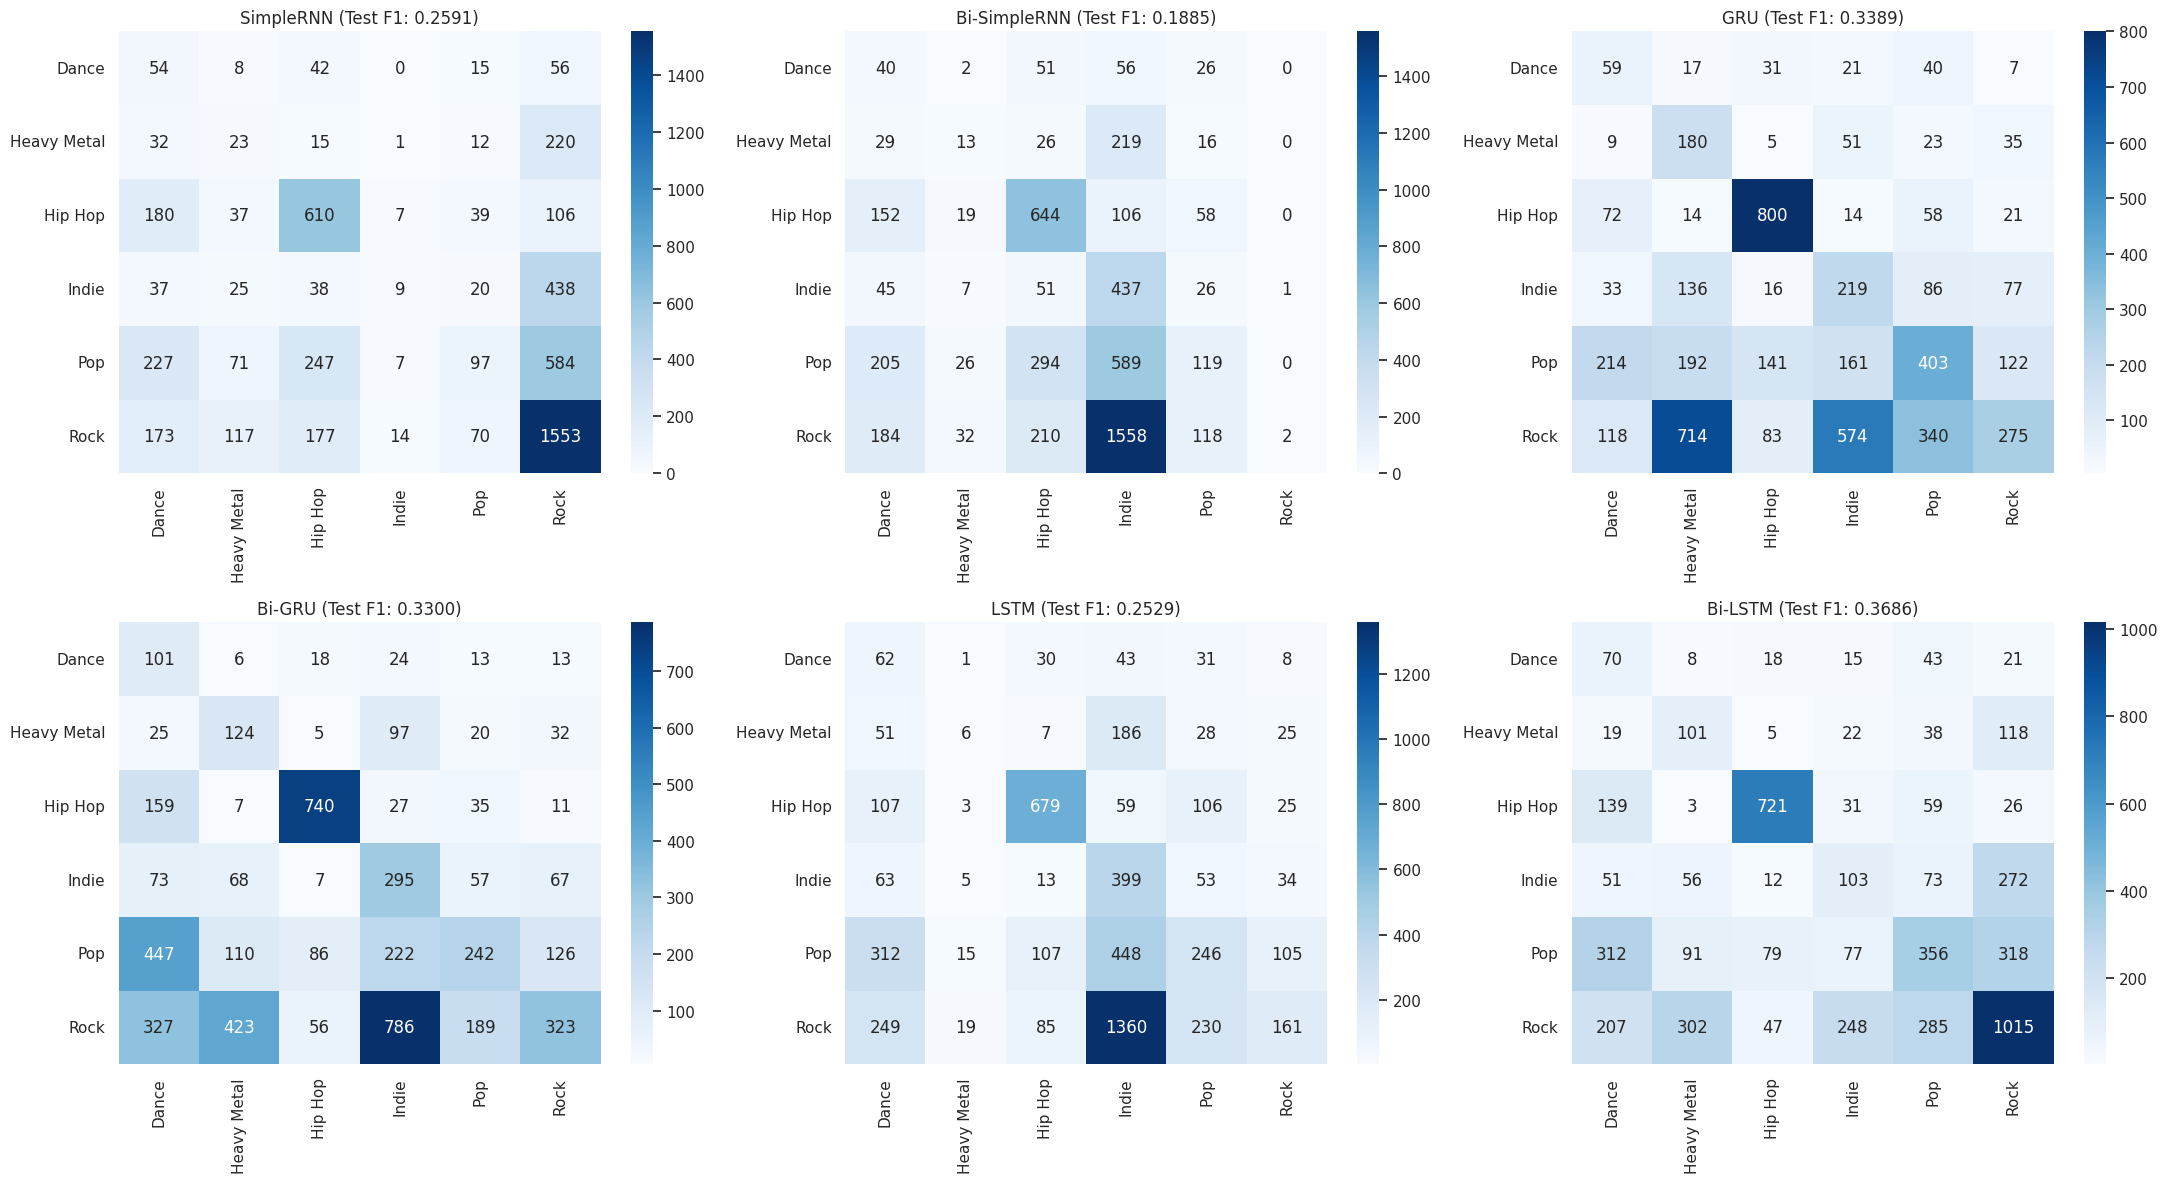

In [25]:
# Cell 21: Test Set Evaluation Grid                                                                                                                                                
import matplotlib.pyplot as plt                                                                                                                                                                          
import seaborn as sns                                                                                                                                                                                    
from sklearn.metrics import classification_report, confusion_matrix                                                                                                                                      
                                                                                                                                                                                                         
fig, axes = plt.subplots(2, 3, figsize=(22, 12))                                                                                                                                                         
axes = axes.flatten()                                                                                                                                                                                    
                                                                                                                                                                                                         
for idx, arch in enumerate(architectures):                                                                                                                                                               
    arch_records = [r for r in tuning_records if r['Model'] == arch and r['Representation'] == 'Keras Embedding']                                                                                        
    best_record = max(arch_records, key=lambda x: x['Val Macro F1'])                                                                                                                                     
                                                                                                                                                                                                         
    print(f"\n{'='*15} {arch.upper()} (BEST: {best_record['Configuration']}) TEST REPORT {'='*15}")                                                                                                      
                                                                                                                                                                                                         
    best_model = trained_pytorch_models[f"{arch}_{best_record['Configuration']}"]                                                                                                                        
    best_model.eval()                                                                                                                                                                                    
                                                                                                                                                                                                         
    test_preds = []                                                                                                                                                                                      
    with torch.no_grad():                                                                                                                                                                                
        for i in range(0, len(X_test_pad), 256):                                                                                                                                                         
            batch = torch.tensor(X_test_pad[i:i+256], dtype=torch.long).to(device)                                                                                                                       
            test_preds.extend(torch.argmax(best_model(batch), 1).cpu().numpy())                                                                                                                          
                                                                                                                                                                                                         
    print(classification_report(y_test_idx, test_preds, target_names=label_encoder.classes_))                                                                                                            
                                                                                                                                                                                                         
    sns.heatmap(confusion_matrix(y_test_idx, test_preds), annot=True, fmt='d', cmap='Blues', ax=axes[idx], xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)                       
    axes[idx].set_title(f"{arch} (Test F1: {f1_score(y_test_idx, test_preds, average='macro'):.4f})")                                                                                                    
                                                                                                                                                                                                         
plt.tight_layout()                                                                                                                                                                                       


# BERT

In [26]:
# Cell 22: Hugging Face Setup & Tokenization
!pip install -q transformers datasets evaluate accelerate

import torch
import evaluate
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)

print("Preparing Hugging Face Datasets...")

# 1. Map your existing encoded labels to a 'labels' column required by Trainer
df_train_hf = pd.DataFrame({'text': df_train['text_dl'], 'labels': y_train_idx})
df_val_hf   = pd.DataFrame({'text': df_val['text_dl'], 'labels': y_val_idx})
df_test_hf  = pd.DataFrame({'text': df_test['text_dl'], 'labels': y_test_idx})

# 2. Convert to Hugging Face Dataset objects
train_hf = Dataset.from_pandas(df_train_hf)
val_hf   = Dataset.from_pandas(df_val_hf)
test_hf  = Dataset.from_pandas(df_test_hf)

# 3. Initialize Tokenizer
model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(batch):
    return tokenizer(batch["text"], truncation=True, max_length=256)

# 4. Tokenize datasets
train_tokenized = train_hf.map(tokenize_function, batched=True)
val_tokenized   = val_hf.map(tokenize_function, batched=True)
test_tokenized  = test_hf.map(tokenize_function, batched=True)

# 5. Dynamic padding collator
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)


Preparing Hugging Face Datasets...


Map:   0%|          | 0/42887 [00:00<?, ? examples/s]

Map:   0%|          | 0/5361 [00:00<?, ? examples/s]

Map:   0%|          | 0/5361 [00:00<?, ? examples/s]

Tokenization Complete!


In [27]:
# Cell 23: Metrics & Model Initialization

# Define evaluation metrics
accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)
    acc = accuracy_metric.compute(predictions=predictions, references=labels)["accuracy"]
    f1 = f1_metric.compute(predictions=predictions, references=labels, average="weighted")["f1"]
    return {"accuracy": acc, "f1_weighted": f1}

# Map IDs to Label Names for the model config
label_names = list(label_encoder.classes_)
id2label = {i: label for i, label in enumerate(label_names)}
label2id = {label: i for i, label in enumerate(label_names)}

# Load BERT-Base Model
bert_model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_classes,
    id2label=id2label,
    label2id=label2id
)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BERT-Base initialized successfully!


In [28]:
# Cell 24: BERT Training Loop with Early Stopping
from transformers import EarlyStoppingCallback

# Set training arguments
training_args = TrainingArguments(
    output_dir="/tmp/bert_genre_classification",
    eval_strategy="epoch",
    save_strategy="epoch",  
    save_total_limit=2,
    learning_rate=2e-5,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    num_train_epochs=10,           # Increased to 10 epochs
    weight_decay=0.01,
    load_best_model_at_end=True,   # Required for early stopping
    metric_for_best_model="f1_weighted",
    fp16=True,
    bf16=False,
    tf32=False,
    logging_steps=100,
    seed=42
)

# Initialize Trainer with Early Stopping
trainer = Trainer(
    model=bert_model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=val_tokenized,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

# Execute Training
print("Starting BERT Fine-tuning with Early Stopping...")


Starting BERT Fine-tuning with Early Stopping...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted
1,1.020326,1.018274,0.606044,0.566254
2,0.910525,0.971867,0.622458,0.600253
3,0.766755,0.992977,0.629547,0.606525
4,0.602476,1.087614,0.615184,0.609547
5,0.475264,1.262599,0.616489,0.599525
6,0.348252,1.369368,0.609028,0.602964
7,0.266946,1.518458,0.615370,0.607551


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

TrainOutput(global_step=4697, training_loss=0.6348605335634364, metrics={'train_runtime': 444.8365, 'train_samples_per_second': 964.107, 'train_steps_per_second': 15.084, 'total_flos': 3.949557181755494e+16, 'train_loss': 0.6348605335634364, 'epoch': 7.0})


==================== BERT-BASE TEST REPORT ====================


              precision    recall  f1-score   support

       Dance       0.51      0.19      0.28       175
 Heavy Metal       0.60      0.32      0.42       303
     Hip Hop       0.92      0.78      0.84       979
       Indie       0.43      0.38      0.41       567
         Pop       0.52      0.61      0.56      1233
        Rock       0.65      0.72      0.69      2104

    accuracy                           0.63      5361
   macro avg       0.60      0.50      0.53      5361
weighted avg       0.64      0.63      0.63      5361



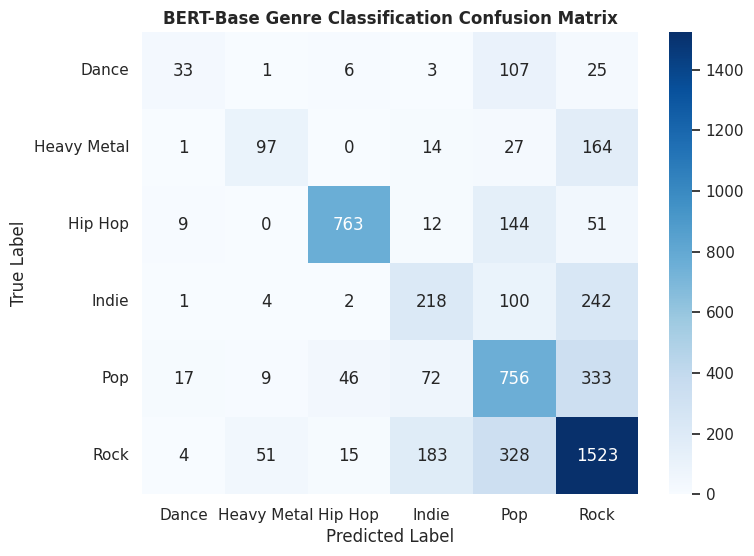

In [29]:
# Cell 25: Test Set Evaluation & Confusion Matrix

print(f"\n{'='*20} BERT-BASE TEST REPORT {'='*20}")

# Predict on the unseen test set
test_predictions = trainer.predict(test_tokenized)
test_pred_labels = np.argmax(test_predictions.predictions, axis=1)
test_true_labels = test_predictions.label_ids

# Print classification report
print(classification_report(test_true_labels, test_pred_labels, target_names=label_names))

# Plot confusion matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(test_true_labels, test_pred_labels)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names)
plt.title('BERT-Base Genre Classification Confusion Matrix', fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')


In [30]:
import pandas as pd                                                                                              
import os                                                                                                        
import torch                                                                                                     
                                                                                                                 
print("Starting Backup...")                                                                                      
                                                                                                                 
# 1. Save your hyperparameter tuning results to a CSV file                                                       
if 'tuning_records' in locals():                                                                                 
    pd.DataFrame(tuning_records).to_csv('rnn_tuning_results_backup.csv', index=False)                            
    print("Tuning records saved to CSV!")                                                                     
                                                                                                                 
# 2. Save all those PyTorch RNN models                                                                           
if 'trained_pytorch_models' in locals():                                                                         
    os.makedirs('saved_rnn_models', exist_ok=True)                                                               
    for model_name, model in trained_pytorch_models.items():                                                     
        torch.save(model.state_dict(), f'saved_rnn_models/{model_name}.pt')                                      
    print("RNN models saved to disk.")                                                     
                                                                                                                 
print("Backup complete.")                                    


Starting Backup...
✅ Tuning records saved to CSV!
✅ All PyTorch RNN models safely saved to disk!
🎉 BACKUP COMPLETE!


In [31]:
# Cell 24: BERT Training Loop with Class Weights & Early Stopping
from torch import nn
from transformers import Trainer, EarlyStoppingCallback
import torch

# 1. Convert your existing sklearn weights array into a PyTorch tensor
tensor_weights = torch.tensor(weights_arr, dtype=torch.float32).to(bert_model.device)

# 2. Subclass the Hugging Face Trainer to inject the weights into the Loss Function
class ClassWeightsTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        # Apply the weighted CrossEntropyLoss
        loss_fct = nn.CrossEntropyLoss(weight=tensor_weights)
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))

        return (loss, outputs) if return_outputs else loss

# 3. Set training arguments
training_args = TrainingArguments(
    output_dir="/tmp/bert_genre_classification_weighted",
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    learning_rate=2e-5,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    num_train_epochs=10,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1_weighted",
    fp16=True,
    bf16=False,
    tf32=False,
    logging_steps=100,
    seed=42
)

# 4. Initialize our CUSTOM Trainer
trainer = ClassWeightsTrainer(     # <--- Using the custom trainer here
    model=bert_model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=val_tokenized,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

# Execute Training
print("Starting Weighted BERT Fine-tuning...")


Starting Weighted BERT Fine-tuning...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted
1,0.524308,1.535796,0.571908,0.576415
2,0.382569,1.615549,0.550830,0.566127
3,0.226409,2.133307,0.594479,0.596102
4,0.126595,2.454604,0.576945,0.585820
5,0.171874,2.491492,0.598582,0.594278
6,0.094045,2.861110,0.609215,0.599134
7,0.085551,2.913883,0.603246,0.602834
8,0.047374,3.216542,0.608282,0.602239
9,0.032865,3.258931,0.607536,0.602170
10,0.026530,3.340600,0.611640,0.607765


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

TrainOutput(global_step=6710, training_loss=0.17228751966699224, metrics={'train_runtime': 627.0174, 'train_samples_per_second': 683.984, 'train_steps_per_second': 10.701, 'total_flos': 5.642224545364992e+16, 'train_loss': 0.17228751966699224, 'epoch': 10.0})


==================== BERT-BASE Weighted TEST REPORT ====================


              precision    recall  f1-score   support

       Dance       0.44      0.30      0.36       175
 Heavy Metal       0.52      0.42      0.46       303
     Hip Hop       0.86      0.82      0.84       979
       Indie       0.40      0.36      0.38       567
         Pop       0.54      0.56      0.55      1233
        Rock       0.65      0.70      0.68      2104

    accuracy                           0.63      5361
   macro avg       0.57      0.53      0.54      5361
weighted avg       0.62      0.63      0.62      5361



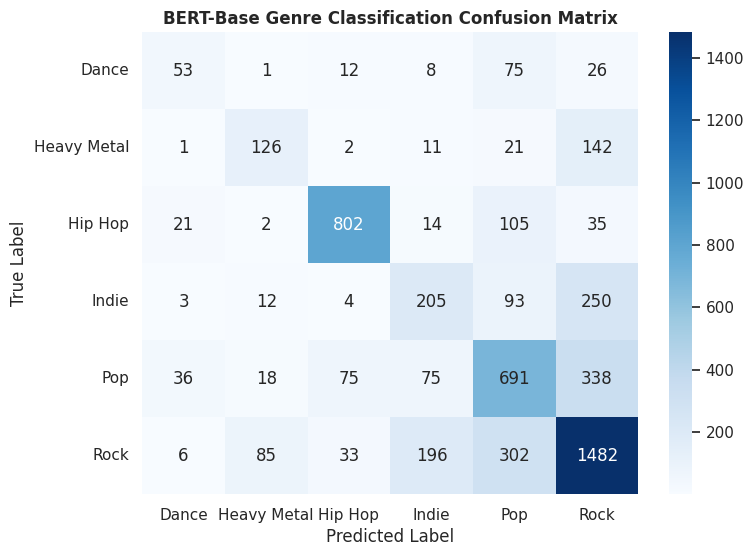

In [32]:
# Cell 25: Test Set Evaluation & Confusion Matrix

print(f"\n{'='*20} BERT-BASE Weighted TEST REPORT {'='*20}")

# Predict on the unseen test set
test_predictions = trainer.predict(test_tokenized)
test_pred_labels = np.argmax(test_predictions.predictions, axis=1)
test_true_labels = test_predictions.label_ids

# Print classification report
print(classification_report(test_true_labels, test_pred_labels, target_names=label_names))

# Plot confusion matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(test_true_labels, test_pred_labels)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names)
plt.title('BERT-Base Genre Classification Confusion Matrix', fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')


In [33]:
# Cell 26: RoBERTa Setup & Weighted Training
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments

roberta_name = "roberta-base"
roberta_tokenizer = AutoTokenizer.from_pretrained(roberta_name)

print("Tokenizing 6-class lyrics data for RoBERTa...")
def tokenize_roberta(batch):
    return roberta_tokenizer(batch["text"], truncation=True, max_length=256)

train_roberta = train_hf.map(tokenize_roberta, batched=True)
val_roberta   = val_hf.map(tokenize_roberta, batched=True)
test_roberta  = test_hf.map(tokenize_roberta, batched=True)

# Load RoBERTa for 6 classes
roberta_model = AutoModelForSequenceClassification.from_pretrained(
    roberta_name,
    num_labels=num_classes,
    id2label=id2label,
    label2id=label2id
).to('cuda' if torch.cuda.is_available() else 'cpu')

# Set training arguments specifically for RoBERTa
roberta_args = TrainingArguments(
    output_dir="/tmp/roberta_genre_classification",
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    learning_rate=2e-5,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    num_train_epochs=20,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1_weighted",
    fp16=True,
    bf16=False,
    tf32=False,
    logging_steps=100,
    seed=42
)

# Use the custom weighted trainer we already defined in memory
roberta_trainer = ClassWeightsTrainer(
    model=roberta_model,
    args=roberta_args,
    train_dataset=train_roberta,
    eval_dataset=val_roberta,
    processing_class=roberta_tokenizer,
    data_collator=DataCollatorWithPadding(tokenizer=roberta_tokenizer),
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

print("Starting Weighted RoBERTa Fine-tuning...")


Tokenizing 6-class lyrics data for RoBERTa...


Map:   0%|          | 0/42887 [00:00<?, ? examples/s]

Map:   0%|          | 0/5361 [00:00<?, ? examples/s]

Map:   0%|          | 0/5361 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=4026, training_loss=0.8589770809311921, metrics={'train_runtime': 375.1321, 'train_samples_per_second': 2286.501, 'train_steps_per_second': 35.774, 'total_flos': 3.385334727218995e+16, 'train_loss': 0.8589770809311921, 'epoch': 6.0})


==================== ROBERTA-BASE Weighted TEST REPORT ====================


              precision    recall  f1-score   support

       Dance       0.19      0.48      0.27       175
 Heavy Metal       0.34      0.62      0.44       303
     Hip Hop       0.87      0.83      0.85       979
       Indie       0.32      0.53      0.40       567
         Pop       0.51      0.39      0.44      1233
        Rock       0.69      0.50      0.58      2104

    accuracy                           0.55      5361
   macro avg       0.49      0.56      0.50      5361
weighted avg       0.61      0.55      0.56      5361



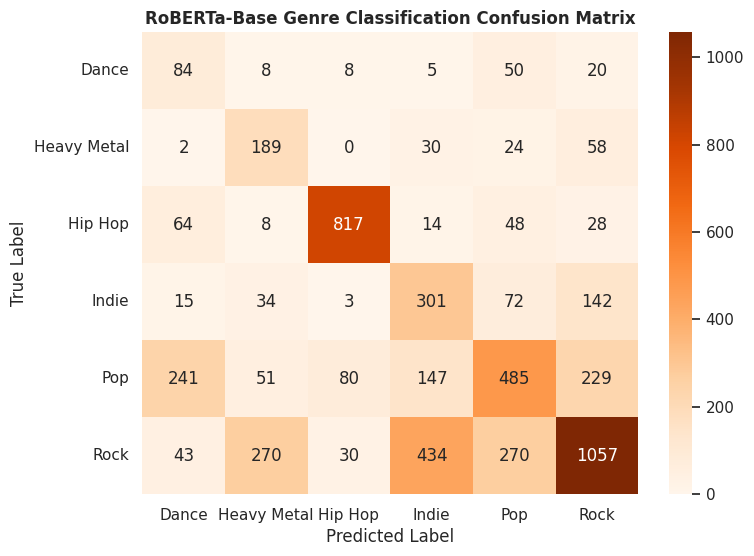

In [34]:
# Cell 27: RoBERTa Test Set Evaluation
print(f"\n{'='*20} ROBERTA-BASE Weighted TEST REPORT {'='*20}")

roberta_predictions = roberta_trainer.predict(test_roberta)
roberta_pred_labels = np.argmax(roberta_predictions.predictions, axis=1)

print(classification_report(test_true_labels, roberta_pred_labels, target_names=label_names))

plt.figure(figsize=(8, 6))
cm_roberta = confusion_matrix(test_true_labels, roberta_pred_labels)
sns.heatmap(cm_roberta, annot=True, fmt='d', cmap='Oranges',
            xticklabels=label_names, yticklabels=label_names)
plt.title('RoBERTa-Base Genre Classification Confusion Matrix', fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')


Running 2-Model Ensemble Inference...
Extracting BERT predictions...


Extracting RoBERTa predictions...



==================== ENSEMBLE MODEL TEST REPORT ====================
              precision    recall  f1-score   support

       Dance       0.44      0.33      0.37       175
 Heavy Metal       0.50      0.43      0.47       303
     Hip Hop       0.87      0.83      0.85       979
       Indie       0.41      0.38      0.40       567
         Pop       0.55      0.56      0.55      1233
        Rock       0.66      0.70      0.68      2104

    accuracy                           0.63      5361
   macro avg       0.57      0.54      0.55      5361
weighted avg       0.63      0.63      0.63      5361



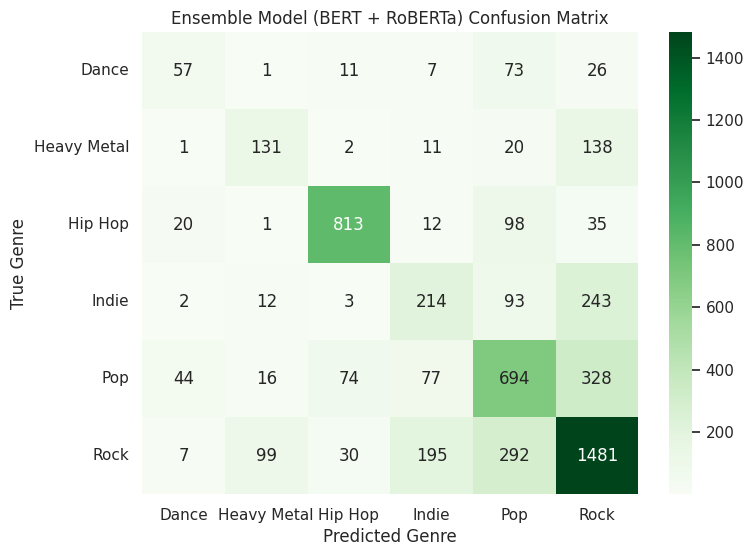

In [48]:
# Cell: Ensemble (Soft Voting of BERT and RoBERTa)                                                               
import torch.nn.functional as F                                                                                  
import torch                                                                                                     
import numpy as np                                                                                               
from sklearn.metrics import classification_report, confusion_matrix                                              
import matplotlib.pyplot as plt                                                                                  
import seaborn as sns                                                                                            
                                                                                                                 
print("Running 2-Model Ensemble Inference...")                                                                   
trainer.optimizer = None                                                                                         
roberta_trainer.optimizer = None     

bert_model.cuda()                                                                                                
roberta_model.cuda()
# 1. Get raw logits from BERT and RoBERTa                                                                        
print("Extracting BERT predictions...")                                                                          
bert_preds = trainer.predict(test_tokenized)                                                                     
                                                                                                                 
print("Extracting RoBERTa predictions...")                                                                       
roberta_preds = roberta_trainer.predict(test_roberta)                                                            
                                                                                                                 
# 2. Convert raw logits to probabilities using Softmax                                                           
bert_probs = F.softmax(torch.tensor(bert_preds.predictions), dim=-1).numpy()                                     
roberta_probs = F.softmax(torch.tensor(roberta_preds.predictions), dim=-1).numpy()                               
                                                                                                                 
# 3. Soft Voting: Average the probabilities across the two models                                                
ensemble_probs = (bert_probs + roberta_probs) / 2.0                                                              
                                                                                                                 
# 4. Final ensemble predictions                                                                                  
ensemble_pred_labels = np.argmax(ensemble_probs, axis=1)                                                         
                                                                                                                 
print(f"\n{'='*20} ENSEMBLE MODEL TEST REPORT {'='*20}")                                                         
print(classification_report(test_true_labels, ensemble_pred_labels, target_names=label_names))                   
                                                                                                                 
# Plot Ensemble Confusion Matrix                                                                                 
plt.figure(figsize=(8, 6))                                                                                       
cm_ensemble = confusion_matrix(test_true_labels, ensemble_pred_labels)                                           
sns.heatmap(cm_ensemble, annot=True, fmt='d', cmap='Greens', xticklabels=label_names, yticklabels=label_names)   
plt.title('Ensemble Model (BERT + RoBERTa) Confusion Matrix')                                                    
plt.ylabel('True Genre')                                                                                         
plt.xlabel('Predicted Genre')                                                                                    


In [49]:
import os                                                                                                        
                                                                                                                 
print("Exporting final models for deployment...")                                                    
os.makedirs("./deployment_models", exist_ok=True)                                                                
                                                                                                                 
# 1. Save the best BERT model & tokenizer                                                                        
trainer.save_model("./deployment_models/best_bert")                                                              
tokenizer.save_pretrained("./deployment_models/best_bert")                                                       
print("Saved BERT")                                                                                           
                                                                                                                 
# 2. Save the best RoBERTa model & tokenizer                                                                     
roberta_trainer.save_model("./deployment_models/best_roberta")                                                   
roberta_tokenizer.save_pretrained("./deployment_models/best_roberta")                                            
print("Saved RoBERTa")                                                                                        
                                                                                                                 


Exporting the absolute best models for deployment...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Saved BERT


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Saved RoBERTa
🎉 Your 2-Model Ensemble is safely saved to the Windows 'deployment_models' folder!
